In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import importlib
import json
import sys

model_paths = [
    "/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/6",
    ''
]

for p in model_paths:
    if Path(p).exists():
        sys.path.insert(0, p)
        break

import pinn_model
pinn_model = importlib.reload(pinn_model)

print(pinn_model.__file__)
print("run_experiment:", hasattr(pinn_model, "run_experiment"))

/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/6/pinn_model.py
run_experiment: True


In [2]:
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = "cuda"
    print("gpu:", torch.cuda.get_device_name(0))
else:
    device = "cpu"

work_dir = Path("/kaggle/working")
if not work_dir.exists():
    work_dir = Path(".")

print("device:", device)
print("work_dir:", work_dir)

torch version: 2.10.0+cu128
cuda available: True
gpu: Tesla T4
device: cuda
work_dir: /kaggle/working


In [3]:
m_values = [8, 9, 10, 11, 12]
dtype_values = ["fp32", "fp64"]
seed_values = [0, 1]

variants = [
    {"variant": "base_2k", "adam_steps": 2000, "lbfgs_steps": 1500, "resample_every": 0, "lbfgs_lr": 0.1, "n_collocation": 5000, "bc_weight": 1.0, "hard_bc": False},
    {"variant": "resample_2k", "adam_steps": 2000, "lbfgs_steps": 1500, "resample_every": 200, "lbfgs_lr": 0.1, "n_collocation": 5000, "bc_weight": 1.0, "hard_bc": False},
    {"variant": "resample_5k", "adam_steps": 5000, "lbfgs_steps": 1500, "resample_every": 200, "lbfgs_lr": 0.1, "n_collocation": 5000, "bc_weight": 1.0, "hard_bc": False},
    {"variant": "soft_lbfgs", "adam_steps": 5000, "lbfgs_steps": 1500, "resample_every": 200, "lbfgs_lr": 0.03, "n_collocation": 5000, "bc_weight": 1.0, "hard_bc": False},
    {"variant": "softer_lbfgs", "adam_steps": 5000, "lbfgs_steps": 1500, "resample_every": 200, "lbfgs_lr": 0.01, "n_collocation": 5000, "bc_weight": 1.0, "hard_bc": False},
    {"variant": "adam_only", "adam_steps": 10000, "lbfgs_steps": 0, "resample_every": 200, "lbfgs_lr": 0.03, "n_collocation": 5000, "bc_weight": 1.0, "hard_bc": False},
    {"variant": "resample_100_soft", "adam_steps": 5000, "lbfgs_steps": 1500, "resample_every": 100, "lbfgs_lr": 0.03, "n_collocation": 5000, "bc_weight": 1.0, "hard_bc": False},
    {"variant": "more_points_soft", "adam_steps": 5000, "lbfgs_steps": 1000, "resample_every": 200, "lbfgs_lr": 0.03, "n_collocation": 10000, "bc_weight": 1.0, "hard_bc": False},
]

runs = []
i = 1
for m in m_values:
    for variant in variants:
        for dtype in dtype_values:
            for seed in seed_values:
                row = variant.copy()
                row["run_id"] = i
                row["m"] = m
                row["dtype"] = dtype
                row["seed"] = seed
                runs.append(row)
                i += 1

pd.DataFrame(runs).head(), len(runs)

(       variant  adam_steps  lbfgs_steps  resample_every  lbfgs_lr  \
 0      base_2k        2000         1500               0       0.1   
 1      base_2k        2000         1500               0       0.1   
 2      base_2k        2000         1500               0       0.1   
 3      base_2k        2000         1500               0       0.1   
 4  resample_2k        2000         1500             200       0.1   
 
    n_collocation  bc_weight  hard_bc  run_id  m dtype  seed  
 0           5000        1.0    False       1  8  fp32     0  
 1           5000        1.0    False       2  8  fp32     1  
 2           5000        1.0    False       3  8  fp64     0  
 3           5000        1.0    False       4  8  fp64     1  
 4           5000        1.0    False       5  8  fp32     0  ,
 160)

In [4]:
base_config = {
    "task_name": "helmholtz1d",
    "dtype": "fp32",
    "seed": 0,
    "device": device,
    "m": 8,
    "lambda_val": 1.0,
    "hid_size": 128,
    "num_layers": 4,
    "n_collocation": 5000,
    "n_bc": 2,
    "adam_steps": 2000,
    "lbfgs_steps": 1500,
    "lr_adam": 5e-4,
    "resample_every": 0,
    "use_adam": True,
    "use_lbfgs": True,
    "lbfgs_tolerance_grad": 1e-12,
    "lbfgs_tolerance_change": 1e-14,
    "lbfgs_history_size": 100,
    "lbfgs_lr": 0.1,
    "lbfgs_line_search_fn": "strong_wolfe",
    "hard_bc": False,
    "bc_weight": 1.0,
    "log_dir": str(work_dir / "runs" / "helmholtz_overnight_tmp"),
}

pd.DataFrame(runs).groupby(["m", "variant", "dtype"]).size().head(20)

m  variant            dtype
8  adam_only          fp32     2
                      fp64     2
   base_2k            fp32     2
                      fp64     2
   more_points_soft   fp32     2
                      fp64     2
   resample_100_soft  fp32     2
                      fp64     2
   resample_2k        fp32     2
                      fp64     2
   resample_5k        fp32     2
                      fp64     2
   soft_lbfgs         fp32     2
                      fp64     2
   softer_lbfgs       fp32     2
                      fp64     2
9  adam_only          fp32     2
                      fp64     2
   base_2k            fp32     2
                      fp64     2
dtype: int64

In [5]:
all_summaries = []
all_histories = {}

for run in runs:
    config = base_config.copy()
    config.update(run)
    config["use_adam"] = config["adam_steps"] > 0
    config["use_lbfgs"] = config["lbfgs_steps"] > 0
    name = f"overnight_r{run['run_id']:03d}_m{run['m']}_{run['variant']}_{run['dtype']}_s{run['seed']}"
    config["log_dir"] = str(work_dir / "runs" / name)

    run_dir = Path(config["log_dir"])
    summary_file = run_dir / "summary.json"
    metrics_file = run_dir / "metrics.csv"

    if summary_file.exists() and metrics_file.exists():
        with open(summary_file) as f:
            summary = json.load(f)
        history = pd.read_csv(metrics_file)
    else:
        history, summary = pinn_model.run_experiment(config)

    best = history.loc[history["l2_error"].idxmin()]
    summary["run_id"] = run["run_id"]
    summary["variant"] = run["variant"]
    summary["m"] = run["m"]
    summary["seed"] = run["seed"]
    summary["adam_steps_config"] = run["adam_steps"]
    summary["lbfgs_steps_config"] = run["lbfgs_steps"]
    summary["resample_every"] = run["resample_every"]
    summary["lbfgs_lr"] = run["lbfgs_lr"]
    summary["n_collocation"] = run["n_collocation"]
    summary["hard_bc"] = run["hard_bc"]
    summary["bc_weight"] = run["bc_weight"]
    summary["best_l2_error"] = float(best["l2_error"])
    summary["best_step"] = int(best["step"])
    summary["l2_ratio"] = float(summary["final_l2_error"] / summary["best_l2_error"])

    all_summaries.append(summary)
    all_histories[name] = history

    print(run["run_id"], run["variant"], "m", run["m"], run["dtype"], "seed", run["seed"], "final", summary["final_l2_error"], "best", summary["best_l2_error"], "time", summary["time_sec"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1 base_2k m 8 fp32 seed 0 final 0.012068157084286213 best 0.008042032830417156 time 74.83208966255188
2 base_2k m 8 fp32 seed 1 final 0.0025971271097660065 best 0.0025971271097660065 time 66.4376769065857
3 base_2k m 8 fp64 seed 0 final 1.8400437865217492 best 0.9997622799937325 time 186.95729279518127
4 base_2k m 8 fp64 seed 1 final 0.0018673380612527339 best 0.001331633562428918 time 205.3513481616974
5 resample_2k m 8 fp32 seed 0 final 1.1427216529846191 best 0.997715950012207 time 46.01609134674072
6 resample_2k m 8 fp32 seed 1 final 0.0021392686758190393 best 0.001877548056654632 time 66.68256115913391
7 resample_2k m 8 fp64 seed 0 final 1.3828068535148959 best 0.9270554297052566 time 186.42975902557373
8 resample_2k m 8 fp64 seed 1 final 1.141842731384254 best 1.0041296372441544 time 186.29968667030334
9 resample_5k m 8 fp32 seed 0 final 2.4742441177368164 best 0.8229723572731018 time 71.7857038974762
10 resample_5k m 8 fp32 seed 1 final 0.016313130035996437 best 0.01631313003599

In [6]:
df = pd.DataFrame(all_summaries)
cols = [
    "run_id", "variant", "task_name", "m", "dtype", "seed",
    "adam_steps_config", "lbfgs_steps_config", "resample_every", "lbfgs_lr",
    "n_collocation", "hard_bc", "bc_weight",
    "final_loss", "final_l2_error", "best_l2_error", "best_step", "l2_ratio", "time_sec", "log_dir",
]
df = df[cols]
df.to_csv(work_dir / "helmholtz_overnight_summary.csv", index=False)
df.sort_values("best_l2_error").head(20)

,run_id,variant,task_name,m,dtype,seed,adam_steps_config,lbfgs_steps_config,resample_every,lbfgs_lr,n_collocation,hard_bc,bc_weight,final_loss,final_l2_error,best_l2_error,best_step,l2_ratio,time_sec,log_dir
3,4,base_2k,helmholtz1d,8,fp64,1,2000,1500,0,0.10,5000,False,1.0,0.000002,0.001867,0.001332,3000,1.402291,205.351348,/kaggle/working/runs/overnight_r004_m8_base_2k...
60,61,more_points_soft,helmholtz1d,9,fp32,0,5000,1000,200,0.03,10000,False,1.0,0.000006,0.001650,0.001650,6000,1.000000,110.466401,/kaggle/working/runs/overnight_r061_m9_more_po...
5,6,resample_2k,helmholtz1d,8,fp32,1,2000,1500,200,0.10,5000,False,1.0,0.000002,0.002139,0.001878,3300,1.139395,66.682561,/kaggle/working/runs/overnight_r006_m8_resampl...
39,40,resample_2k,helmholtz1d,9,fp64,1,2000,1500,200,0.10,5000,False,1.0,0.000003,0.002120,0.002120,3500,1.000000,207.146477,/kaggle/working/runs/overnight_r040_m9_resampl...
26,27,resample_100_soft,helmholtz1d,8,fp64,0,5000,1500,100,0.03,5000,False,1.0,0.000004,0.003595,0.002519,6200,1.427146,317.223669,/kaggle/working/runs/overnight_r027_m8_resampl...
1,2,base_2k,helmholtz1d,8,fp32,1,2000,1500,0,0.10,5000,False,1.0,0.000010,0.002597,0.002597,3500,1.000000,66.437677,/kaggle/working/runs/overnight_r002_m8_base_2k...
29,30,more_points_soft,helmholtz1d,8,fp32,1,5000,1000,200,0.03,10000,False,1.0,0.000003,0.006708,0.003040,5600,2.207060,109.496531,/kaggle/working/runs/overnight_r030_m8_more_po...
24,25,resample_100_soft,helmholtz1d,8,fp32,0,5000,1500,100,0.03,5000,False,1.0,0.000004,0.003126,0.003126,6100,1.000000,95.204702,/kaggle/working/runs/overnight_r025_m8_resampl...
62,63,more_points_soft,helmholtz1d,9,fp64,0,5000,1000,200,0.03,10000,False,1.0,0.000007,0.069354,0.003313,5700,20.931780,521.820825,/kaggle/working/runs/overnight_r063_m9_more_po...
45,46,soft_lbfgs,helmholtz1d,9,fp32,1,5000,1500,200,0.03,5000,False,1.0,0.000004,0.003366,0.003366,6500,1.000000,97.285326,/kaggle/working/runs/overnight_r046_m9_soft_lb...


In [7]:
grouped = df.groupby(["variant", "m", "dtype"]).agg(
    best_l2_median=("best_l2_error", "median"),
    best_l2_min=("best_l2_error", "min"),
    final_l2_median=("final_l2_error", "median"),
    ok_1e_2=("best_l2_error", lambda x: float((x < 1e-2).mean())),
    ok_5e_2=("best_l2_error", lambda x: float((x < 5e-2).mean())),
    time_median=("time_sec", "median"),
).reset_index()

grouped.to_csv(work_dir / "helmholtz_overnight_grouped.csv", index=False)
grouped.sort_values(["m", "best_l2_median"]).head(40)

,variant,m,dtype,best_l2_median,best_l2_min,final_l2_median,ok_1e_2,ok_5e_2,time_median
10,base_2k,8,fp32,0.005320,0.002597,0.007333,1.0,1.0,70.634883
20,more_points_soft,8,fp32,0.009189,0.003040,0.024423,0.5,1.0,109.089646
21,more_points_soft,8,fp64,0.023950,0.007903,0.025569,0.5,1.0,521.078238
1,adam_only,8,fp64,0.180629,0.145910,0.249809,0.0,0.0,371.110963
0,adam_only,8,fp32,0.249723,0.193313,0.371378,0.0,0.0,87.675249
31,resample_100_soft,8,fp64,0.356539,0.002519,0.605545,0.5,0.5,308.109911
60,soft_lbfgs,8,fp32,0.414307,0.005641,1.242559,0.5,0.5,84.453872
70,softer_lbfgs,8,fp32,0.416863,0.010754,1.242499,0.0,0.5,90.109754
50,resample_5k,8,fp32,0.419643,0.016313,1.245279,0.0,0.5,82.196393
30,resample_100_soft,8,fp32,0.484243,0.003126,0.579748,0.5,0.5,84.416332


In [8]:
best_pivot = grouped.pivot_table(
    index=["variant", "m"],
    columns="dtype",
    values="best_l2_median",
    aggfunc="first",
).reset_index()

best_pivot["fp64_over_fp32"] = best_pivot["fp64"] / best_pivot["fp32"]
best_pivot.to_csv(work_dir / "helmholtz_overnight_fp64_ratio.csv", index=False)
best_pivot.sort_values("fp64_over_fp32").head(40)

dtype,variant,m,fp32,fp64,fp64_over_fp32
32,soft_lbfgs,10,0.468451,0.025462,0.054354
37,softer_lbfgs,10,0.845535,0.073659,0.087116
16,resample_100_soft,9,0.866723,0.385692,0.445001
27,resample_5k,10,0.845535,0.426958,0.504956
21,resample_2k,9,0.910112,0.501068,0.550556
0,adam_only,8,0.249723,0.180629,0.723317
15,resample_100_soft,8,0.484243,0.356539,0.736282
1,adam_only,9,0.610380,0.502554,0.823346
4,adam_only,12,0.771165,0.635413,0.823964
14,more_points_soft,12,0.993659,0.892295,0.897989


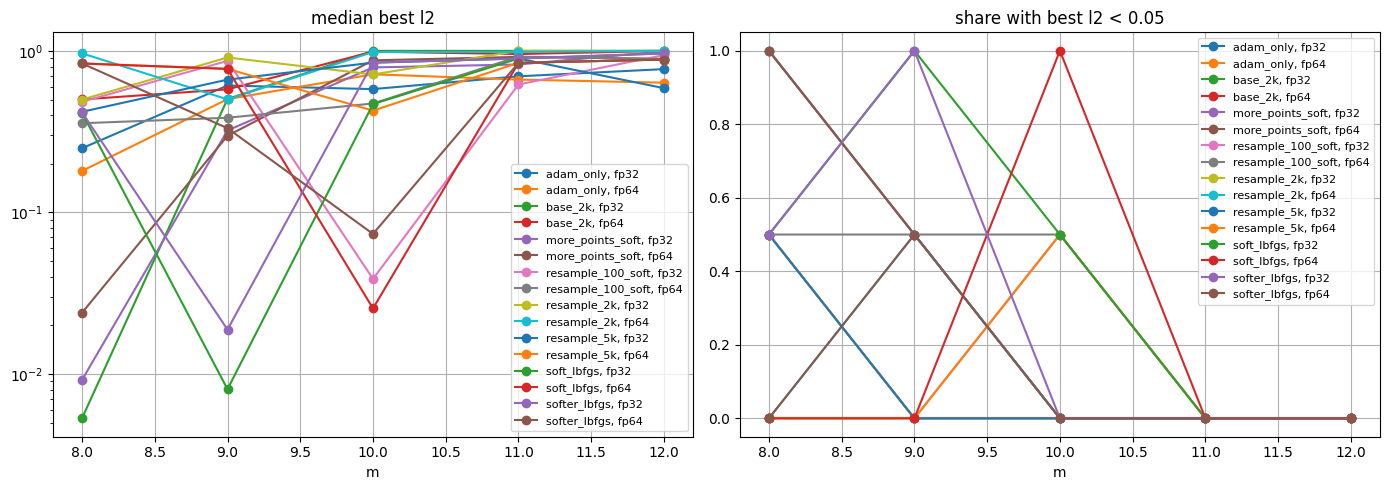

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for variant in grouped["variant"].unique():
    for dtype in dtype_values:
        cur = grouped[(grouped["variant"] == variant) & (grouped["dtype"] == dtype)].sort_values("m")
        if len(cur) == 0:
            continue
        label = f"{variant}, {dtype}"
        ax[0].plot(cur["m"], cur["best_l2_median"], marker="o", label=label)
        ax[1].plot(cur["m"], cur["ok_5e_2"], marker="o", label=label)

ax[0].set_title("median best l2")
ax[1].set_title("share with best l2 < 0.05")
ax[0].set_yscale("log")
for a in ax:
    a.set_xlabel("m")
    a.grid(True)
    a.legend(fontsize=8)

fig.tight_layout()
plt.show()

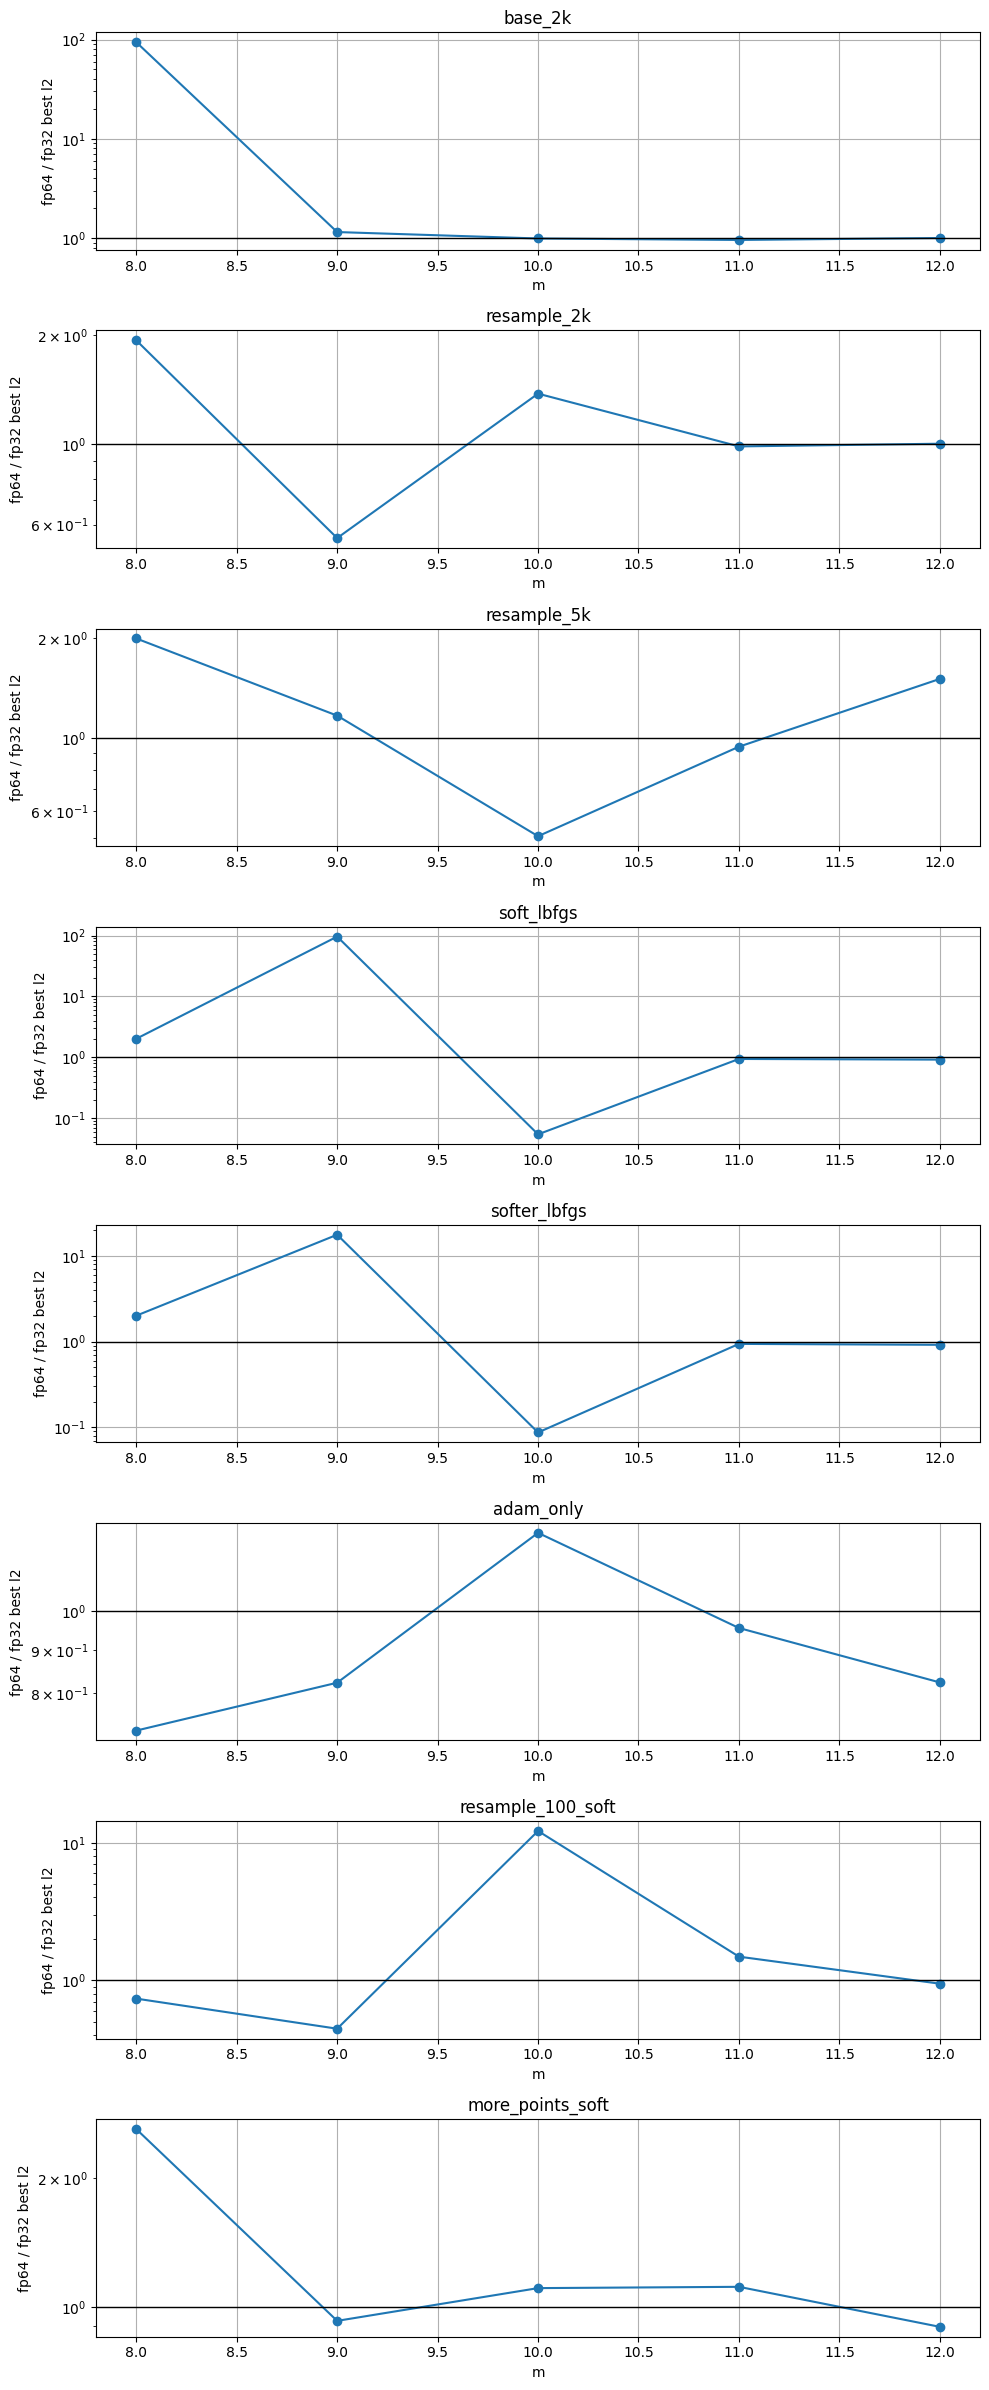

In [10]:
fig, ax = plt.subplots(len(variants), 1, figsize=(10, 3 * len(variants)))
ax = np.array(ax).reshape(len(variants))

for i, variant in enumerate([v["variant"] for v in variants]):
    cur = best_pivot[best_pivot["variant"] == variant].sort_values("m")
    ax[i].plot(cur["m"], cur["fp64_over_fp32"], marker="o")
    ax[i].axhline(1.0, color="black", linewidth=1)
    ax[i].set_title(variant)
    ax[i].set_xlabel("m")
    ax[i].set_ylabel("fp64 / fp32 best l2")
    ax[i].set_yscale("log")
    ax[i].grid(True)

fig.tight_layout()
plt.show()

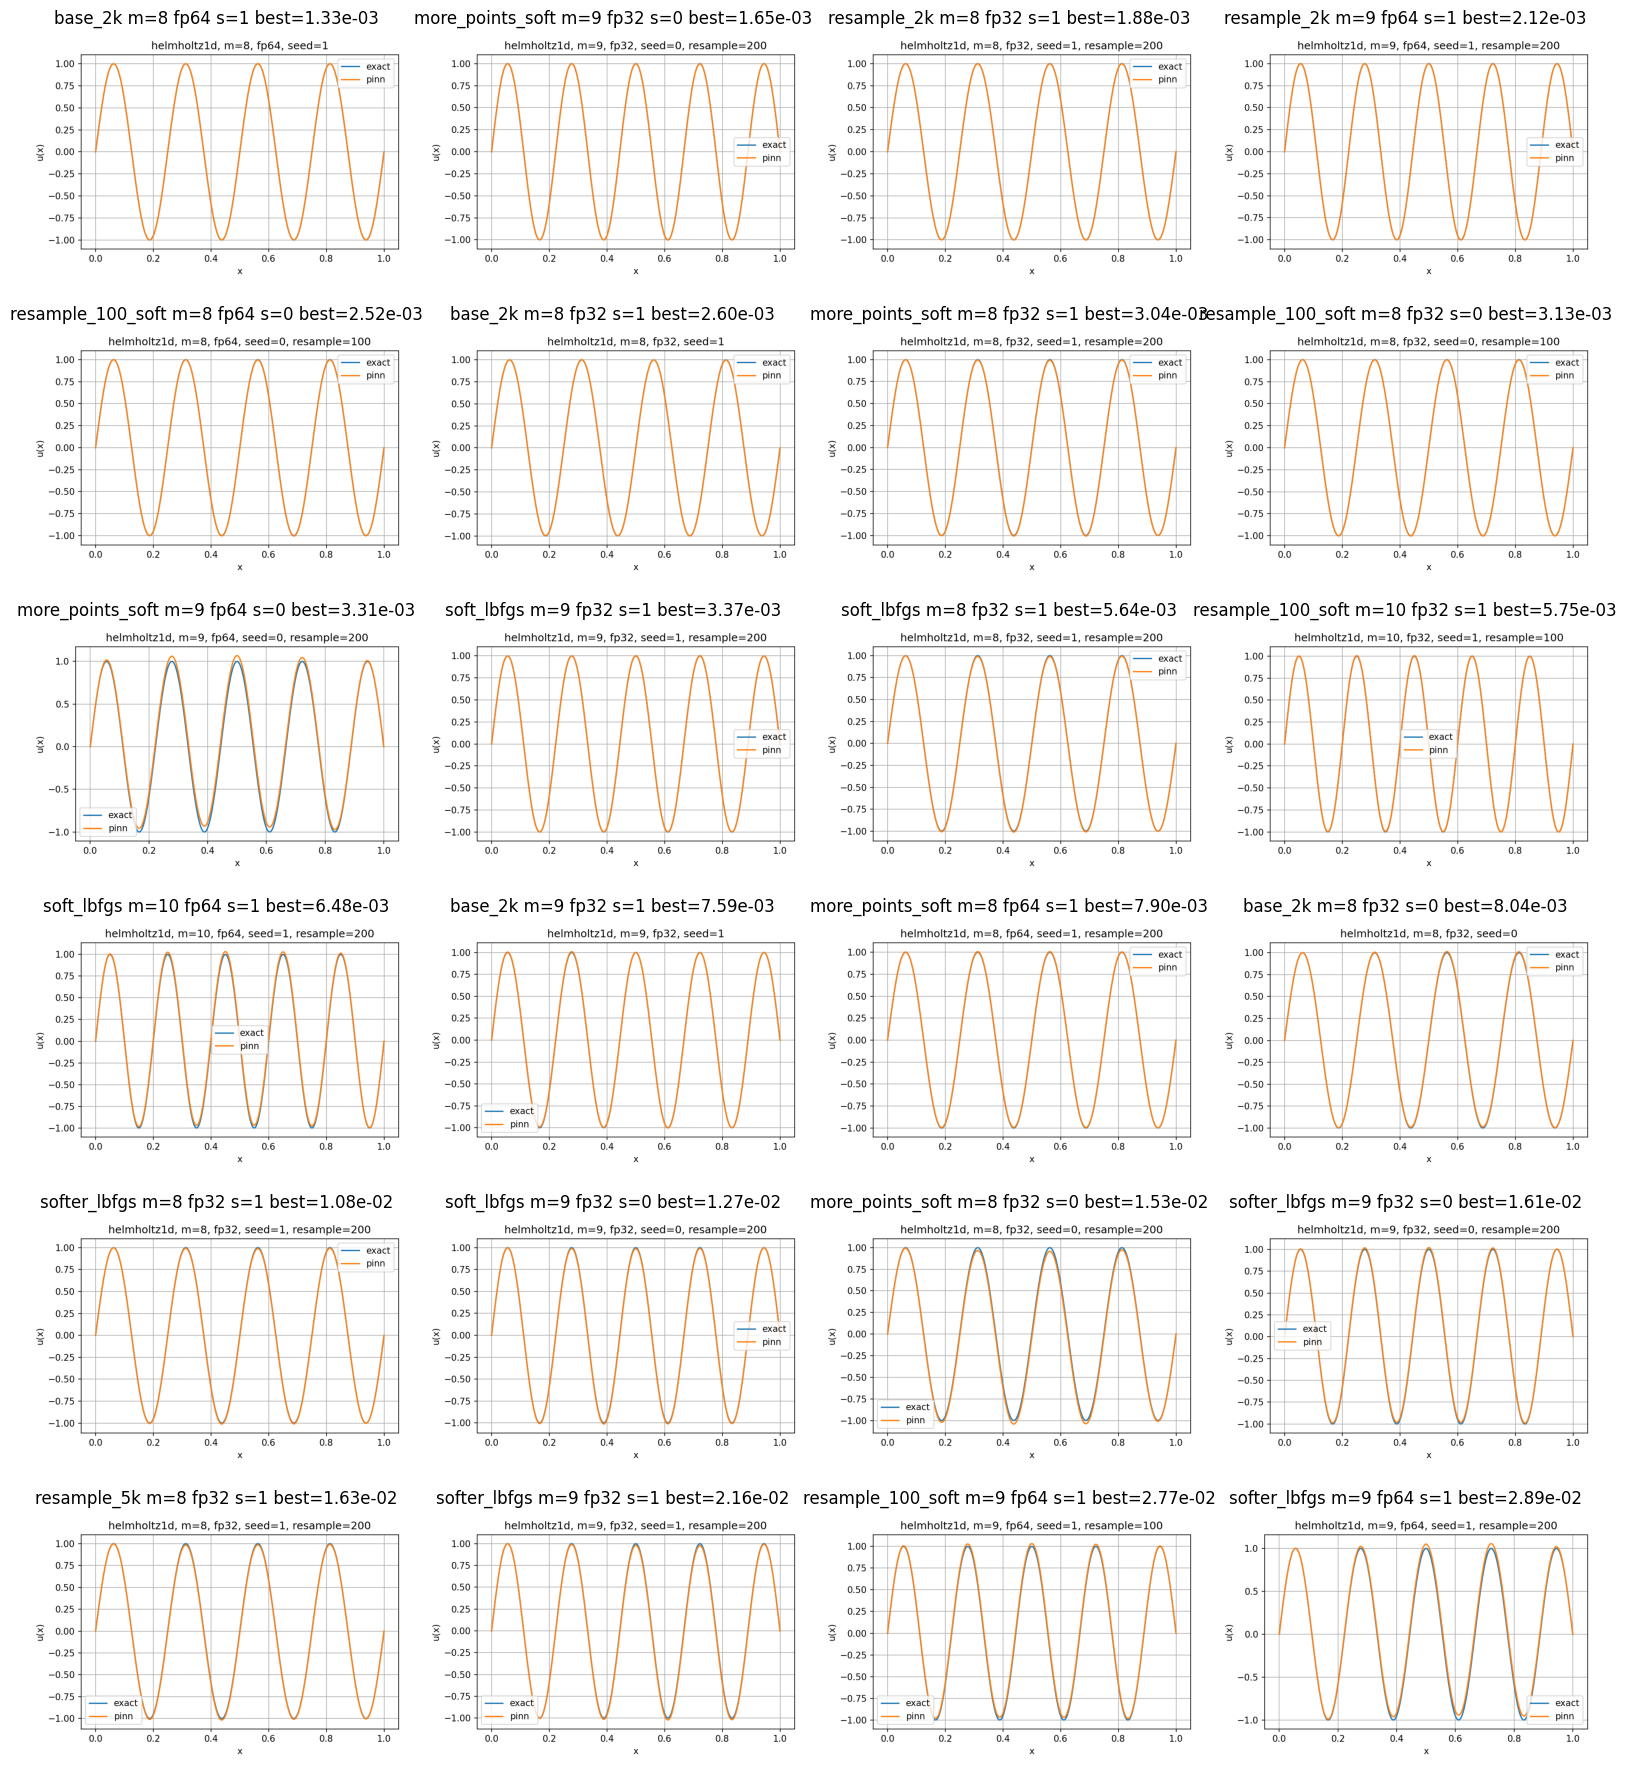

In [11]:
show = df.sort_values("best_l2_error").head(24)
rows = 6
cols = 4
fig, ax = plt.subplots(rows, cols, figsize=(16, 18))
ax = np.array(ax).reshape(rows, cols)

for k in range(rows * cols):
    r = k // cols
    c = k % cols
    ax[r, c].axis("off")
    if k >= len(show):
        continue
    row = show.iloc[k]
    p = Path(row["log_dir"]) / "solution_t1.png"
    ax[r, c].set_title(f"{row['variant']} m={row['m']} {row['dtype']} s={row['seed']} best={row['best_l2_error']:.2e}")
    if p.exists():
        img = plt.imread(p)
        ax[r, c].imshow(img)

fig.tight_layout()
plt.show()

In [12]:
bad = df.sort_values("best_l2_error", ascending=False).head(12)
bad[["variant", "m", "dtype", "seed", "final_l2_error", "best_l2_error", "best_step", "l2_ratio", "log_dir"]]

,variant,m,dtype,seed,final_l2_error,best_l2_error,best_step,l2_ratio,log_dir
135,resample_2k,12,fp64,1,1.025114,1.004502,200,1.020520,/kaggle/working/runs/overnight_r136_m12_resamp...
71,resample_2k,10,fp64,1,1.076045,1.004340,400,1.071395,/kaggle/working/runs/overnight_r072_m10_resamp...
7,resample_2k,8,fp64,1,1.141843,1.004130,200,1.137147,/kaggle/working/runs/overnight_r008_m8_resampl...
67,base_2k,10,fp64,1,1.004128,1.003861,900,1.000266,/kaggle/working/runs/overnight_r068_m10_base_2...
129,base_2k,12,fp32,1,1.042427,1.000334,100,1.042079,/kaggle/working/runs/overnight_r130_m12_base_2...
131,base_2k,12,fp64,1,1.749573,1.000326,2000,1.749003,/kaggle/working/runs/overnight_r132_m12_base_2...
97,base_2k,11,fp32,1,1.023954,1.000325,200,1.023622,/kaggle/working/runs/overnight_r098_m11_base_2...
134,resample_2k,12,fp64,0,1.357925,1.000101,100,1.357787,/kaggle/working/runs/overnight_r135_m12_resamp...
130,base_2k,12,fp64,0,8.121797,1.000101,100,8.120973,/kaggle/working/runs/overnight_r131_m12_base_2...
132,resample_2k,12,fp32,0,1.002646,1.000052,600,1.002594,/kaggle/working/runs/overnight_r133_m12_resamp...
